In [1]:
import  pandas  as  pd 
import numpy  as  np


In [2]:
df  = pd.read_csv('/home/joox/Desktop/Ai/classical-ml&& DL /classical-ml/projects/1 project-nyc-taxi-trip-duration/split_sample/train.csv')

In [3]:
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,N,799
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,N,374
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,N,696
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,N,703


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   str    
 1   vendor_id           5000 non-null   int64  
 2   pickup_datetime     5000 non-null   str    
 3   passenger_count     5000 non-null   int64  
 4   pickup_longitude    5000 non-null   float64
 5   pickup_latitude     5000 non-null   float64
 6   dropoff_longitude   5000 non-null   float64
 7   dropoff_latitude    5000 non-null   float64
 8   store_and_fwd_flag  5000 non-null   str    
 9   trip_duration       5000 non-null   int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 390.8 KB


In [5]:
df.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

### Initial observations

- The sample contains 5,000 trips and 10 columns.
- No missing values were found.
- No duplicated rows were found.
- `pickup_datetime` was loaded as a string and should be converted to datetime.

In [7]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

In [8]:
df["pickup_datetime"].dtype

dtype('<M8[us]')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  5000 non-null   str           
 1   vendor_id           5000 non-null   int64         
 2   pickup_datetime     5000 non-null   datetime64[us]
 3   passenger_count     5000 non-null   int64         
 4   pickup_longitude    5000 non-null   float64       
 5   pickup_latitude     5000 non-null   float64       
 6   dropoff_longitude   5000 non-null   float64       
 7   dropoff_latitude    5000 non-null   float64       
 8   store_and_fwd_flag  5000 non-null   str           
 9   trip_duration       5000 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(3), str(2)
memory usage: 390.8 KB


In [10]:
df['vendor_id'].value_counts()

vendor_id
2    2600
1    2400
Name: count, dtype: int64

In [11]:
df['vendor_id'].unique()

array([1, 2])

- `vendor_id` contains two categories: 1 and 2.
- Their distribution is fairly balanced: 2400 vs 2600 trips.

In [12]:
df.groupby(['vendor_id'])['trip_duration'].median()

vendor_id
1    656.0
2    655.5
Name: trip_duration, dtype: float64

In [13]:
df['hour'] = df['pickup_datetime'].dt.hour

In [14]:
df.groupby(['hour'])['trip_duration'].median()

hour
0     664.0
1     599.0
2     635.5
3     669.0
4     750.0
5     532.5
6     498.0
7     520.0
8     675.0
9     671.0
10    686.0
11    665.0
12    668.0
13    681.0
14    717.0
15    756.5
16    684.0
17    671.5
18    638.5
19    670.0
20    616.5
21    578.5
22    664.0
23    708.0
Name: trip_duration, dtype: float64

In [15]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'hour'],
      dtype='str')

In [16]:
pickup_points = df[['pickup_latitude', 'pickup_longitude']].to_numpy()
print(pickup_points)
print(pickup_points.shape)

[[ 40.75106812 -73.99064636]
 [ 40.74507141 -73.98265839]
 [ 40.72858047 -73.9994812 ]
 ...
 [ 40.68924332 -73.95132446]
 [ 40.74370956 -73.98374176]
 [ 40.78493881 -73.95586395]]
(5000, 2)


In [17]:
dropoff_points = df[['dropoff_latitude', 'dropoff_longitude']].to_numpy()
print(dropoff_points)
print(dropoff_points.shape)

[[ 40.7281456  -73.99578857]
 [ 40.73297119 -74.00325775]
 [ 40.71879959 -74.00025177]
 ...
 [ 40.68382263 -73.97595978]
 [ 40.76050949 -73.98753357]
 [ 40.80211639 -73.95340729]]
(5000, 2)


In [18]:
!pip install haversine

In [19]:
from haversine import haversine, Unit, haversine_vector

distances = haversine_vector(pickup_points, dropoff_points, unit=Unit.KILOMETERS)
print(distances)

[2.58542756 2.19599141 1.08952301 ... 2.1628819  1.89517821 1.92122579]


In [20]:
len(distances), len(df)

(5000, 5000)

In [21]:
df['distance_km'] = distances

In [22]:
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525,22,2.585428
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,N,799,12,2.195991
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,N,374,0,1.089523
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,N,696,15,2.902090
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,N,703,13,2.114922


In [23]:
df['distance_km'].describe()

count    5000.000000
mean        3.413398
std         3.877827
min         0.000000
25%         1.245021
50%         2.100700
75%         3.832186
max        42.353730
Name: distance_km, dtype: float64

feat: add trip distance feature using haversine

In [24]:
df[df["distance_km"] == 0]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
159,id3861625,2,2016-04-05 13:15:30,1,-73.980934,40.781628,-73.980934,40.781628,N,1953,13,0.0
179,id1245825,1,2016-03-25 12:02:22,1,-70.851616,43.017578,-70.851616,43.017578,N,1486,12,0.0
198,id1558683,1,2016-03-07 20:12:42,3,-73.983017,40.762505,-73.983017,40.762505,N,608,20,0.0
270,id3633178,2,2016-03-31 22:02:29,1,-73.791618,40.661228,-73.791618,40.661228,N,2208,22,0.0
325,id3218773,2,2016-01-07 14:37:17,2,-74.177292,40.695190,-74.177292,40.695190,N,18,14,0.0
387,id1976758,1,2016-01-11 21:29:02,1,-73.935616,40.857029,-73.935616,40.857029,N,2,21,0.0
683,id3836531,2,2016-03-17 07:50:35,1,-73.968048,40.792152,-73.968048,40.792152,N,570,7,0.0
1122,id1681316,2,2016-01-29 05:10:04,1,-73.979713,40.754848,-73.979713,40.754848,N,611,5,0.0
1471,id1881728,2,2016-05-10 06:42:14,1,-73.925232,40.747330,-73.925232,40.747330,N,336,6,0.0
1539,id3793868,1,2016-01-30 13:46:49,1,-73.974960,40.718998,-73.974960,40.718998,N,2291,13,0.0


- Some trips have zero Haversine distance because their recorded pickup and dropoff coordinates are identical.
- This does not necessarily mean the taxi did not move, because Haversine measures only the straight-line distance between the recorded start and end points.
- These records will be kept for now and investigated further rather than removed automatically.

In [25]:
df[df["distance_km"] <= 42.35]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525,22,2.585428
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,N,799,12,2.195991
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,N,374,0,1.089523
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,N,696,15,2.902090
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,N,703,13,2.114922
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,id0201807,2,2016-01-29 11:53:44,1,-73.978348,40.756149,-73.984970,40.741791,N,542,11,1.691249
4996,id0195215,2,2016-05-12 18:07:39,1,-73.965240,40.754917,-73.963531,40.754341,N,74,18,0.157557
4997,id2987373,2,2016-03-03 21:30:48,5,-73.951324,40.689243,-73.975960,40.683823,N,409,21,2.162882
4998,id1026507,1,2016-06-04 20:45:44,1,-73.983742,40.743710,-73.987534,40.760509,N,763,20,1.895178


In [26]:
df.nlargest(10, 'distance_km')

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
2247,id1561128,2,2016-01-28 21:43:02,1,-73.950462,40.775799,-73.654800,41.084320,N,85828,21,42.353730
63,id3181715,2,2016-05-22 13:53:45,1,-73.783699,40.648720,-73.923637,40.840260,N,2984,13,24.343327
3653,id1078536,1,2016-02-26 23:25:45,4,-73.788872,40.641117,-73.944221,40.824944,N,1914,23,24.272524
3200,id1666147,2,2016-03-31 18:28:08,6,-73.776680,40.645416,-73.968254,40.802074,N,2840,18,23.750246
987,id2054250,1,2016-02-04 06:39:34,1,-73.968758,40.791264,-73.776573,40.644924,N,2231,6,22.959189
4543,id1665858,2,2016-04-28 09:09:50,1,-73.998238,40.761009,-73.776421,40.645199,N,3422,9,22.703829
2376,id3984532,2,2016-06-02 01:22:38,1,-73.780533,40.646149,-73.990334,40.773178,N,2021,1,22.632572
3538,id1498879,2,2016-04-25 14:39:14,5,-73.789513,40.643421,-73.981750,40.784859,N,4531,14,22.580071
3774,id3049585,1,2016-03-28 20:16:06,2,-73.782616,40.644459,-73.984184,40.778019,N,2690,20,22.565521
1004,id1848896,2,2016-06-17 06:20:46,1,-73.792099,40.645187,-73.972336,40.793682,N,2705,6,22.435864


In [27]:
df.nlargest(10, 'trip_duration')

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
1262,id3594467,2,2016-05-18 00:15:00,2,-74.013252,40.707062,-73.958649,40.688332,N,86329,0,5.052512
3687,id1829617,2,2016-06-10 21:12:54,3,-73.996613,40.723701,-73.989532,40.747810,N,86233,21,2.746359
3311,id3805971,2,2016-01-01 03:26:28,5,-73.983711,40.676174,-73.966148,40.690178,N,86209,3,2.148927
4421,id0053174,2,2016-05-01 12:33:49,1,-73.984909,40.747860,-73.978477,40.758518,N,86135,12,1.303100
2430,id3389632,2,2016-02-27 18:18:50,2,-73.979408,40.766972,-73.984039,40.759590,N,85917,18,0.908737
3315,id3213293,2,2016-04-23 13:00:51,2,-74.014160,40.702648,-73.996117,40.741898,N,85891,13,4.621648
2247,id1561128,2,2016-01-28 21:43:02,1,-73.950462,40.775799,-73.654800,41.084320,N,85828,21,42.353730
601,id2760914,2,2016-06-26 03:29:20,1,-73.989479,40.720390,-73.990334,40.728790,N,85295,3,0.936806
2799,id0259764,2,2016-05-31 13:56:41,1,-73.979622,40.759258,-73.807869,40.722298,N,75015,13,15.042368
3637,id2596986,1,2016-04-12 08:51:36,1,-73.781776,40.644714,-73.985909,40.759949,N,7489,8,21.454532


In [28]:
df[df["trip_duration"] >= 72000]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
601,id2760914,2,2016-06-26 03:29:20,1,-73.989479,40.720390,-73.990334,40.728790,N,85295,3,0.936806
1262,id3594467,2,2016-05-18 00:15:00,2,-74.013252,40.707062,-73.958649,40.688332,N,86329,0,5.052512
2247,id1561128,2,2016-01-28 21:43:02,1,-73.950462,40.775799,-73.654800,41.084320,N,85828,21,42.353730
2430,id3389632,2,2016-02-27 18:18:50,2,-73.979408,40.766972,-73.984039,40.759590,N,85917,18,0.908737
2799,id0259764,2,2016-05-31 13:56:41,1,-73.979622,40.759258,-73.807869,40.722298,N,75015,13,15.042368
3311,id3805971,2,2016-01-01 03:26:28,5,-73.983711,40.676174,-73.966148,40.690178,N,86209,3,2.148927
3315,id3213293,2,2016-04-23 13:00:51,2,-74.014160,40.702648,-73.996117,40.741898,N,85891,13,4.621648
3687,id1829617,2,2016-06-10 21:12:54,3,-73.996613,40.723701,-73.989532,40.747810,N,86233,21,2.746359
4421,id0053174,2,2016-05-01 12:33:49,1,-73.984909,40.747860,-73.978477,40.758518,N,86135,12,1.303100


- 9 trips (0.18% of the sample) have durations greater than 20 hours.
- These trips are rare and suspicious because their distances vary widely while their durations are extremely high.
- They will not be removed automatically at this stage.

In [29]:
!pip  install matplotlib seaborn

In [30]:
import matplotlib.pyplot as plt

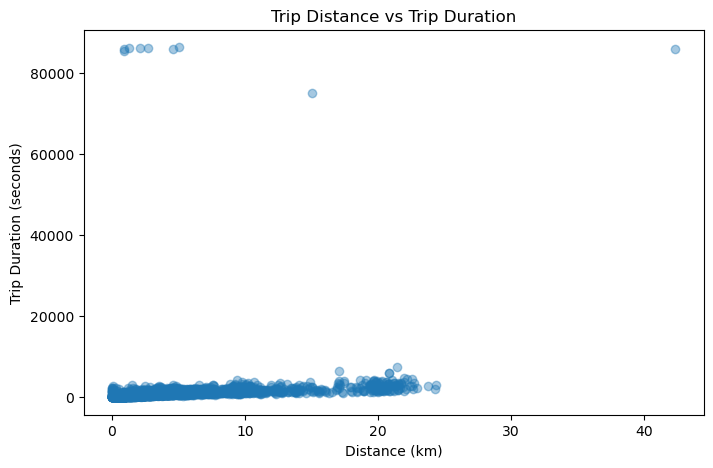

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_km"],
    df["trip_duration"],
    alpha=0.4
)

plt.xlabel("Distance (km)")
plt.ylabel("Trip Duration (seconds)")
plt.title("Trip Distance vs Trip Duration")

plt.show()

In [32]:


# Log transformation
df['log_trip_duration'] = np.log1p(df['trip_duration'])  # log(1+x) to avoid log(0)



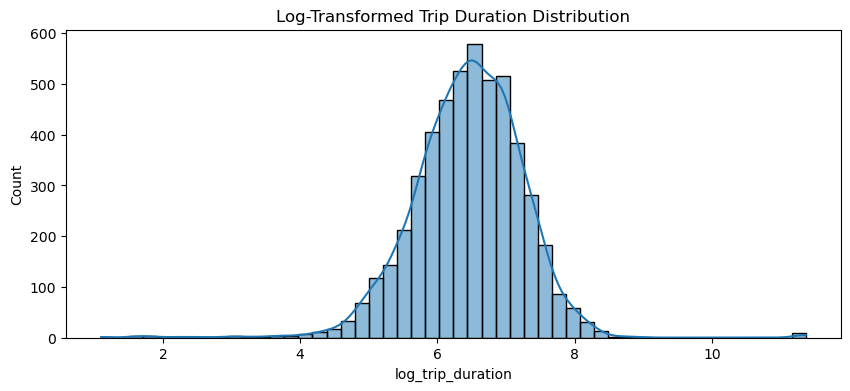

In [33]:
import seaborn as sns

# After log transformation
plt.figure(figsize=(10,4))
sns.histplot(df['log_trip_duration'], bins=50, kde=True)
plt.title("Log-Transformed Trip Duration Distribution")

plt.show()



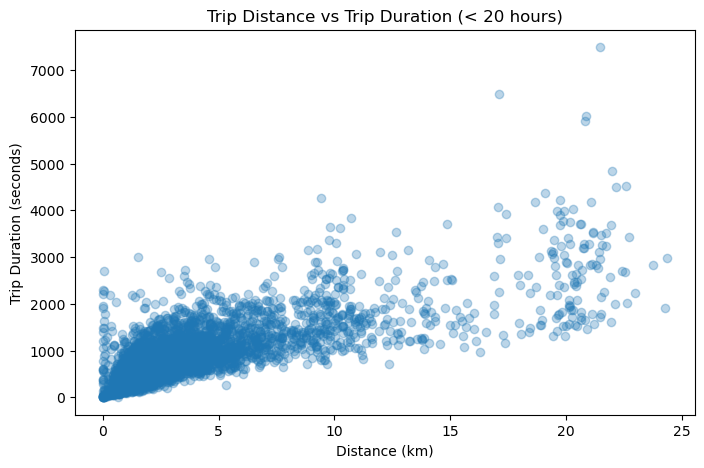

In [34]:
df_plot = df[df["trip_duration"] < 72000]

plt.figure(figsize=(8, 5))

plt.scatter(
    df_plot["distance_km"],
    df_plot["trip_duration"],
    alpha=0.3
)

plt.xlabel("Distance (km)")
plt.ylabel("Trip Duration (seconds)")
plt.title("Trip Distance vs Trip Duration (< 20 hours)")

plt.show()

In [35]:
df['dayofweek'] = df['pickup_datetime'].dt.dayofweek

In [36]:
df['dayofweek'] = df['pickup_datetime'].dt.dayofweek

   train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])
    train['dayofweek'] = train.pickup_datetime.dt.dayofweek
    train['month'] = train.pickup_datetime.dt.month
    train['hour'] = train.pickup_datetime.dt.hour
    train['dayofyear'] = train.pickup_datetime.dt.dayofyear

In [37]:
df['month'] = df['pickup_datetime'].dt.month

In [38]:
df["dayofweek"] = df['pickup_datetime'].dt.dayofweek

In [39]:
df.head(1)

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km,log_trip_duration,dayofweek,month
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525,22,2.585428,6.265301,4,1


In [40]:
df['dayofweek'].value_counts()

dayofweek
4    769
5    761
2    754
3    737
1    690
0    658
6    631
Name: count, dtype: int64

In [41]:
df.groupby(['dayofweek'])['trip_duration'].median()

dayofweek
0    601.5
1    668.0
2    653.0
3    697.0
4    688.0
5    636.0
6    621.0
Name: trip_duration, dtype: float64

In [42]:
#df['month'] = df['pickup_datetime'].dt.month 
df['month'].value_counts()

month
3    901
2    863
5    833
4    822
6    800
1    781
Name: count, dtype: int64

In [43]:
df.groupby(['month'])['trip_duration'].median()

month
1    624.0
2    641.0
3    653.0
4    644.0
5    673.0
6    700.5
Name: trip_duration, dtype: float64

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  5000 non-null   str           
 1   vendor_id           5000 non-null   int64         
 2   pickup_datetime     5000 non-null   datetime64[us]
 3   passenger_count     5000 non-null   int64         
 4   pickup_longitude    5000 non-null   float64       
 5   pickup_latitude     5000 non-null   float64       
 6   dropoff_longitude   5000 non-null   float64       
 7   dropoff_latitude    5000 non-null   float64       
 8   store_and_fwd_flag  5000 non-null   str           
 9   trip_duration       5000 non-null   int64         
 10  hour                5000 non-null   int32         
 11  distance_km         5000 non-null   float64       
 12  log_trip_duration   5000 non-null   float64       
 13  dayofweek           5000 non-null   int32         
 14  mon

In [45]:
df['passenger_count'].value_counts()

passenger_count
1    3542
2     734
5     300
3     208
6     137
4      79
Name: count, dtype: int64

In [46]:
df.groupby(['passenger_count'])['trip_duration'].median()

passenger_count
1     651.0
2     684.5
3     626.5
4    1000.0
5     623.0
6     656.0
Name: trip_duration, dtype: float64

In [47]:
(df["distance_km"] <= 0.1).sum()

np.int64(49)

In [48]:
(df["distance_km"] <= 0.1).mean() * 100

np.float64(0.98)

In [49]:
(df["distance_km"] <= 0.1).mean() * 100

np.float64(0.98)

In [50]:
df[df["distance_km"] <= 0.1]["trip_duration"].describe()

count      49.000000
mean      660.653061
std       774.075835
min         2.000000
25%        20.000000
50%       380.000000
75%      1055.000000
max      2710.000000
Name: trip_duration, dtype: float64

In [51]:
df['same_location'] = df["distance_km"] <= 0.1

In [52]:
df.groupby("same_location")["trip_duration"].median()

same_location
False    657.0
True     380.0
Name: trip_duration, dtype: float64

In [53]:
df["lat_diff"] = df["dropoff_latitude"] - df["pickup_latitude"]

df["lon_diff"] = df["dropoff_longitude"] - df["pickup_longitude"]

In [54]:
df[["lat_diff", "lon_diff"]].describe()

,lat_diff,lon_diff
count,5000.000000,5000.000000
mean,0.000909,0.001354
std,0.032183,0.044182
min,-0.191174,-0.228439
25%,-0.013423,-0.010950
50%,0.000469,0.001816
75%,0.014020,0.014080
max,0.308521,0.295662


In [55]:
df.head(1)

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km,log_trip_duration,dayofweek,month,same_location,lat_diff,lon_diff
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525,22,2.585428,6.265301,4,1,False,-0.022923,-0.005142


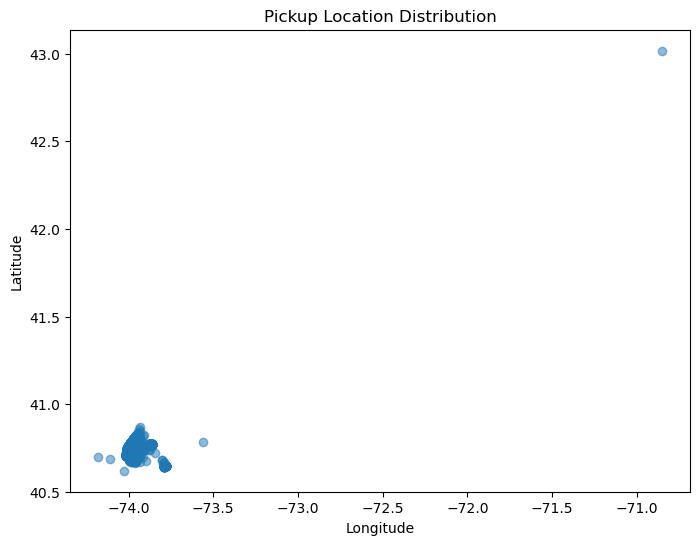

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["pickup_longitude"],
    df["pickup_latitude"],
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pickup Location Distribution")

plt.show()

In [57]:
df.nlargest(5, "pickup_latitude")

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km,log_trip_duration,dayofweek,month,same_location,lat_diff,lon_diff
179,id1245825,1,2016-03-25 12:02:22,1,-70.851616,43.017578,-70.851616,43.017578,N,1486,12,0.000000,7.304516,4,3,True,0.000000,0.000000
520,id3352054,1,2016-05-21 19:54:23,1,-73.930084,40.867867,-73.936058,40.843533,N,717,19,2.752065,6.576470,5,5,False,-0.024334,-0.005974
387,id1976758,1,2016-01-11 21:29:02,1,-73.935616,40.857029,-73.935616,40.857029,N,2,21,0.000000,1.098612,0,1,True,0.000000,0.000000
853,id2137101,2,2016-01-29 22:33:25,3,-73.934746,40.843796,-73.951599,40.824364,N,682,22,2.584423,6.526495,4,1,False,-0.019432,-0.016853
138,id3759049,1,2016-05-11 07:54:13,2,-73.942703,40.837284,-73.955437,40.819878,N,282,7,2.212247,5.645447,2,5,False,-0.017406,-0.012733


In [58]:
df.nlargest(5, "pickup_longitude")

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km,log_trip_duration,dayofweek,month,same_location,lat_diff,lon_diff
179,id1245825,1,2016-03-25 12:02:22,1,-70.851616,43.017578,-70.851616,43.017578,N,1486,12,0.000000,7.304516,4,3,True,0.000000,0.000000
621,id3022813,1,2016-06-15 18:02:41,1,-73.558289,40.781223,-73.558281,40.781227,N,37,18,0.000770,3.637586,2,6,True,0.000004,0.000008
4673,id1870835,1,2016-02-27 21:02:46,2,-73.776337,40.645271,-73.784935,40.665691,N,562,21,2.383649,6.333280,5,2,False,0.020420,-0.008598
3325,id3712387,2,2016-05-23 13:23:36,4,-73.776627,40.645329,-73.787300,40.689301,N,728,13,4.971654,6.591674,0,5,False,0.043972,-0.010674
424,id1210588,1,2016-03-23 13:40:48,2,-73.776642,40.645191,-73.976242,40.671082,N,3297,13,17.081376,8.101072,2,3,False,0.025890,-0.199600


In [59]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'hour',
       'distance_km', 'log_trip_duration', 'dayofweek', 'month',
       'same_location', 'lat_diff', 'lon_diff'],
      dtype='str')

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  5000 non-null   str           
 1   vendor_id           5000 non-null   int64         
 2   pickup_datetime     5000 non-null   datetime64[us]
 3   passenger_count     5000 non-null   int64         
 4   pickup_longitude    5000 non-null   float64       
 5   pickup_latitude     5000 non-null   float64       
 6   dropoff_longitude   5000 non-null   float64       
 7   dropoff_latitude    5000 non-null   float64       
 8   store_and_fwd_flag  5000 non-null   str           
 9   trip_duration       5000 non-null   int64         
 10  hour                5000 non-null   int32         
 11  distance_km         5000 non-null   float64       
 12  log_trip_duration   5000 non-null   float64       
 13  dayofweek           5000 non-null   int32         
 14  mon

## Store and Forward Flag

In [61]:
df["store_and_fwd_flag"].value_counts()

df.groupby("store_and_fwd_flag")["trip_duration"].median()


store_and_fwd_flag
N    655.5
Y    741.5
Name: trip_duration, dtype: float64

Observation: Check if store_and_fwd_flag groups have different trip durations.

In [62]:


# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns



/tmp/ipykernel_487944/3973552272.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [63]:
numerical_cols , categorical_cols

(Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
        'dropoff_longitude', 'dropoff_latitude', 'trip_duration', 'distance_km',
        'log_trip_duration', 'lat_diff', 'lon_diff'],
       dtype='str'),
 Index(['id', 'store_and_fwd_flag'], dtype='str'))

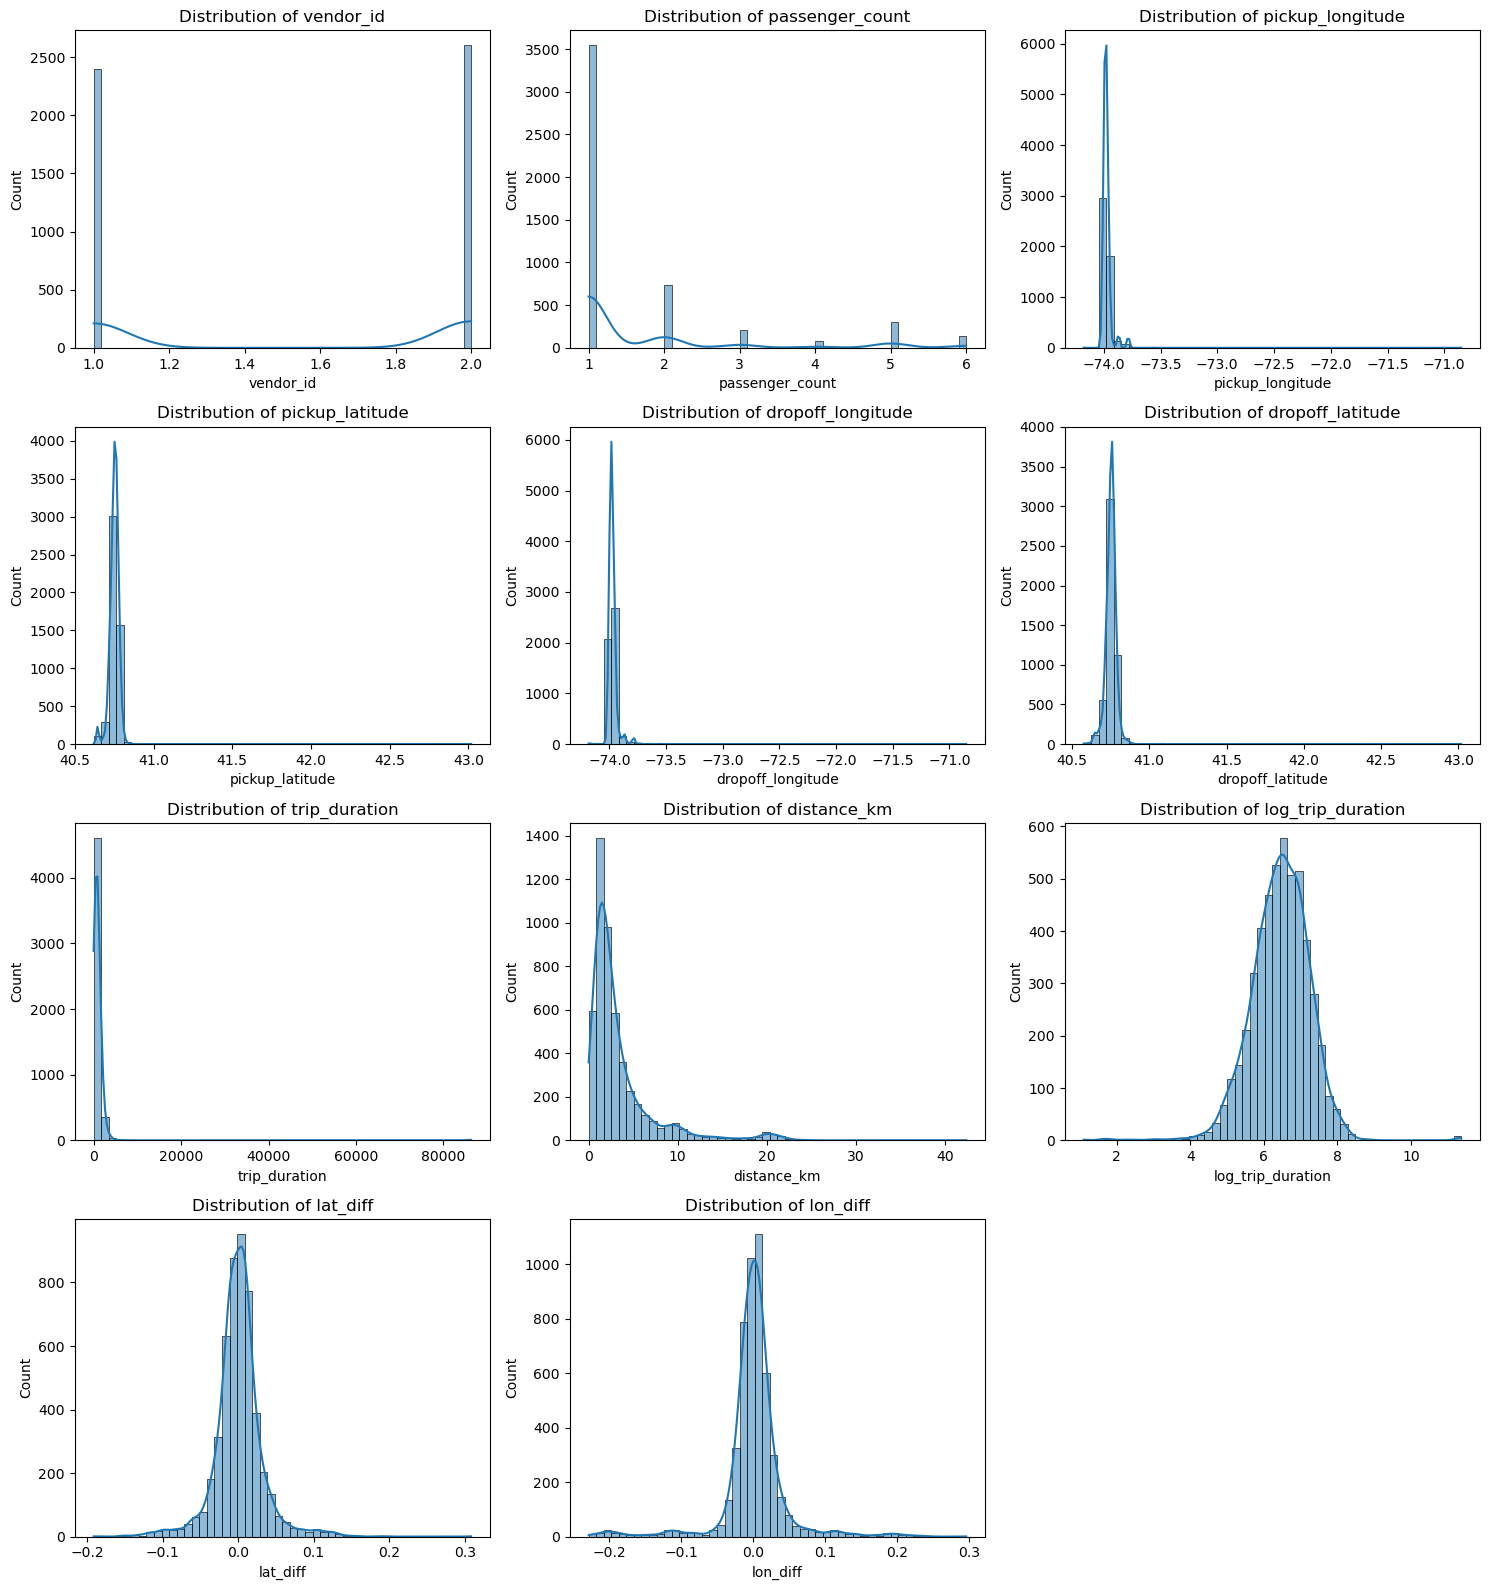

In [68]:
import math
#  Take a sample of the data to speed up plotting
sample_df = df.sample(
    min(10000, len(df)),
    random_state=42
)

n = len(numerical_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 4*nrows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        sample_df[col],
        bins=50,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



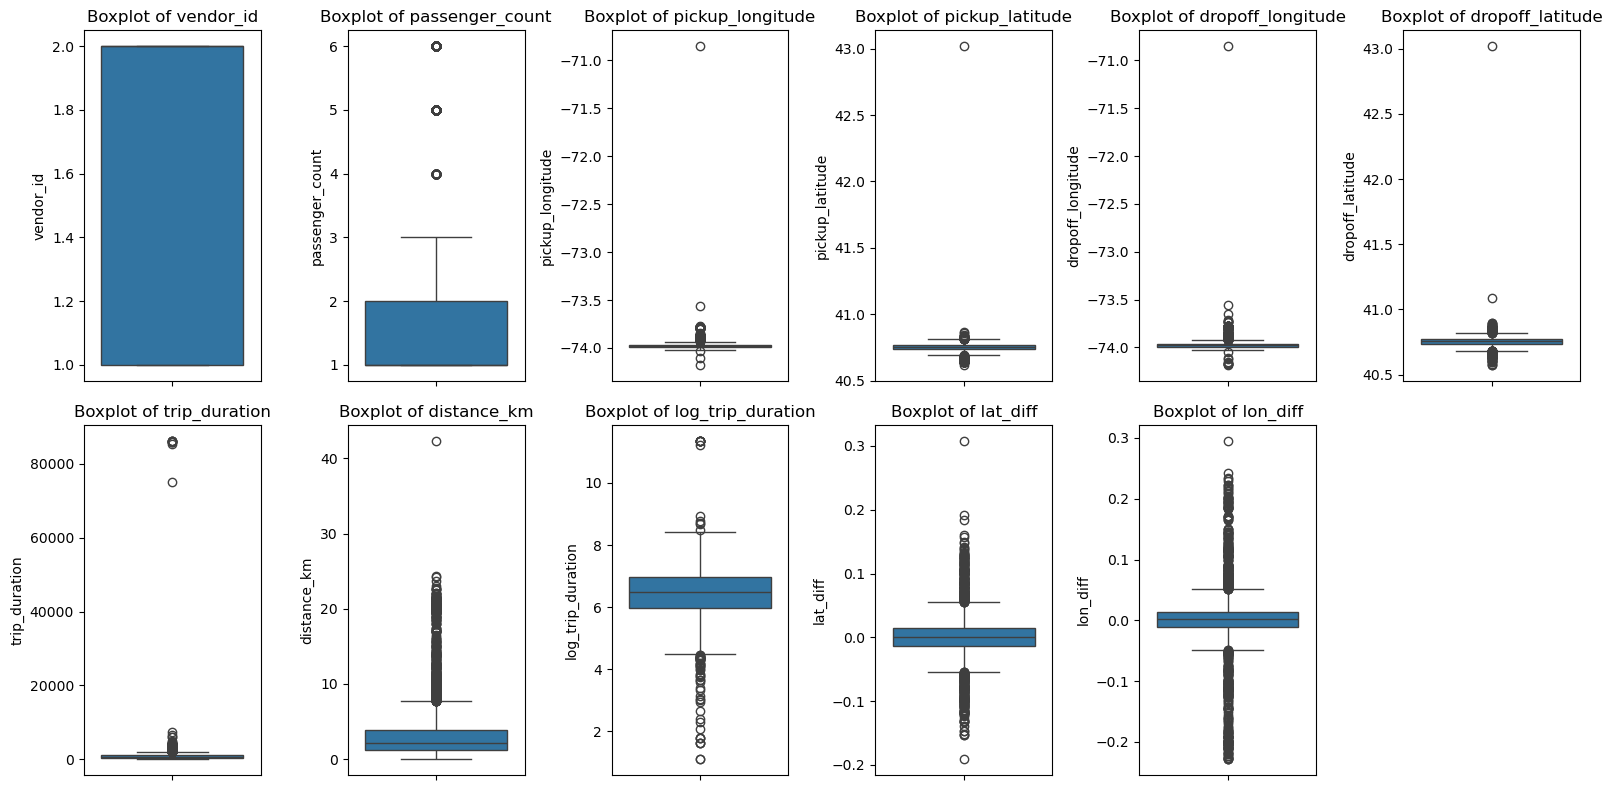

In [66]:


# Number of numerical features
n = len(numerical_cols)

# Create a grid (for example: 2 rows × 4 columns depending on feature count)
fig, axes = plt.subplots(2, (n+1)//2, figsize=(16,8))
axes = axes.flatten()

# Plot each numerical feature in its own boxplot
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

# Hide empty subplots if the grid is not completely filled
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

